# Introduction to Data Modeling with PyTorch

## Setup

### Import Packages

In [68]:
import matplotlib.pyplot as plt
import torch
from torch import nn, optim

---

## Section 1: Generating Data

### Exercises

**Example**: Print the values of a tensor made up of `[1.2, 2.3]`.

In [69]:
torch.tensor([1.2, 2.3])

tensor([1.2000, 2.3000])

**Exercise**: Print the values of a tensor made up of `[1.5, 2.8, 0.7]`.

In [71]:
torch.tensor([1.5, 2.8, 0.7])

tensor([1.5000, 2.8000, 0.7000])

**Exercise**: Create a tensor with 5 random, normally-distributed data points.

In [72]:
torch.empty(5).normal_()

tensor([-1.4327,  1.4079, -0.2480, -0.4072,  1.1227])

**Exercise**: Create a tensor with 10 random, uniformly-distributed data points between the values **2** and **6**.

In [73]:
torch.empty(10).uniform_(2, 6)

tensor([5.8673, 2.6233, 3.7259, 4.3740, 3.1110, 5.8393, 2.6211, 3.8891, 2.5315,
        4.5552])

**Example**: Plot all the values in `x` with `plt.eventplot(x)`, which contains 100 uniformly-distributed data points between the values **-2** and **4**.

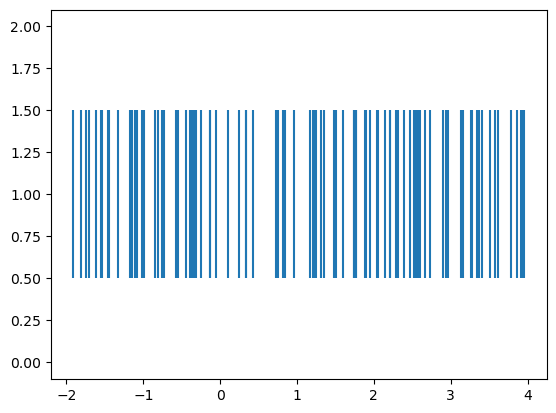

In [26]:
x = torch.empty(100).uniform_(-2, 4)
plt.eventplot(x);

**Example**: Plot a scatterplot with `plt.scatter(x, y)`, showing the relationship between:
  - **x**: 100 normally-distributed random data points
  - **y**: also 100 normally-distributed random data points

Text(0, 0.5, 'y')

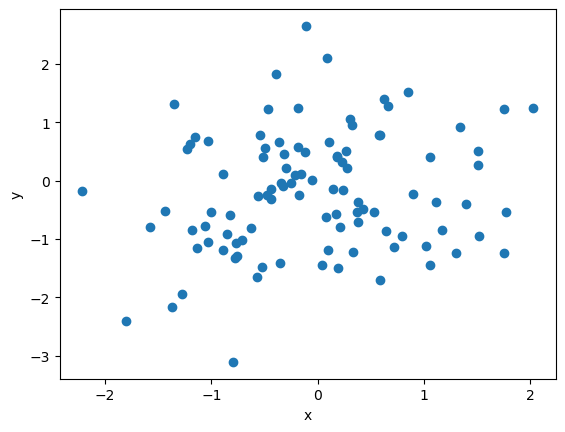

In [62]:
x = torch.empty(100).normal_()
y = torch.empty(100).normal_()
plt.scatter(x, y);
plt.xlabel('x')
plt.ylabel('y')

**Exercise**: Plot a scatterplot with `plt.scatter(x, y)`, showing the relationship between:
  - **`x`**: 100 normally-distributed random data points
  - **`y`**: 5 times `x` plus 100

Text(0, 0.5, 'y')

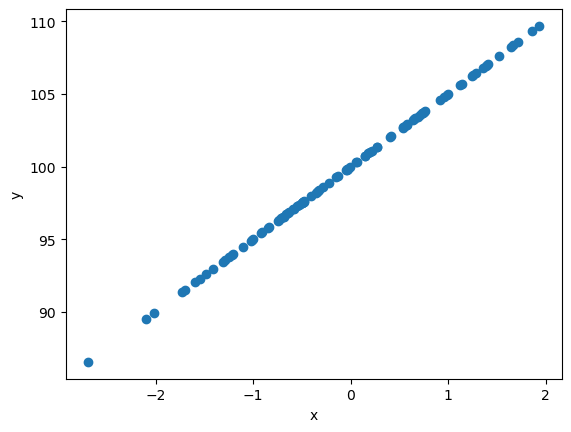

In [63]:
x = torch.empty(100).normal_()
y = 5 * x + 100
plt.scatter(x, y);
plt.xlabel('x')
plt.ylabel('y')

**Exercise**: Plot a scatterplot with `plt.scatter(x, y)`, showing the relationship between:
  - **`x`**: 100 normally-distributed random data points
  - **`y`**: -3 times `x`, plus some **noise** (another 100 normally-distributed random data points)

Text(0, 0.5, 'y')

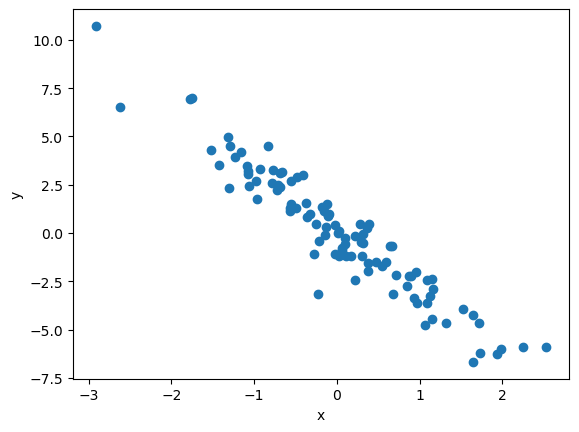

In [64]:
x = torch.empty(100).normal_()
y = -3 * x + torch.empty(100).normal_()
plt.scatter(x, y);
plt.xlabel('x')
plt.ylabel('y')

**Exercise**: Plot a colored scatterplot with `plt.scatter(x1, x2, c=y, cmap='viridis')`, showing the relationship between:
  - **`x1`**: 100 normally-distributed random data points
  - **`x2`**: 100 normally-distributed random data points
  - **`y`**: -3 times `x1` plus 2 times `x2`, plus some **noise** (another 100 normally-distributed random data points)

*Tip*: Add `plt.colorbar(label='y')` after the plotting code to show the values of `y`.

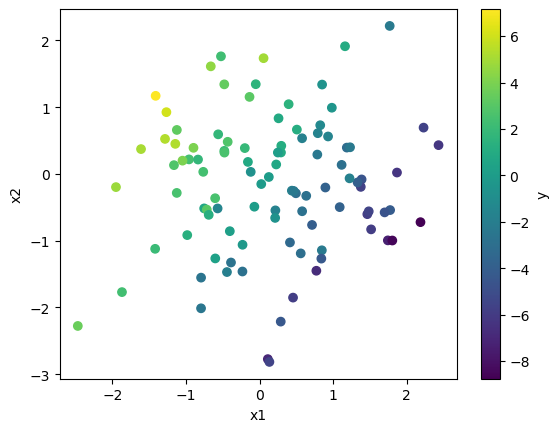

In [66]:
x1 = torch.empty(100).normal_()
x2 = torch.empty(100).normal_()
y = -3 * x1 + 2 * x2 + torch.empty(100).normal_()
plt.scatter(x1, x2, c=y);
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(label='y');

## Modeling Data: Linear Regression

### Exercises

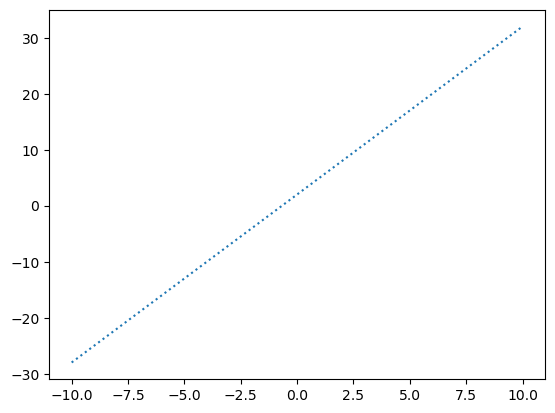

In [78]:
x = torch.linspace(-10, 10, 5)
y = 3 * x + 2
plt.plot(x, y, ':');

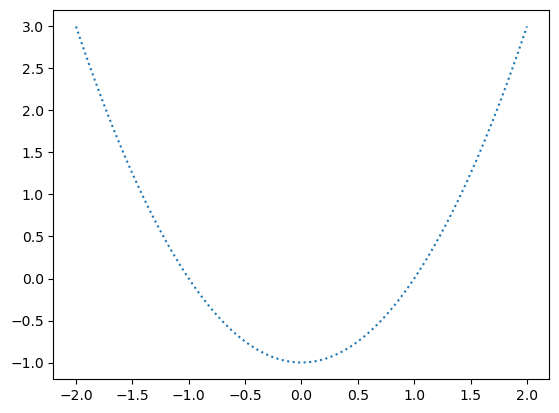

In [83]:
x = torch.linspace(-2, 2, 100)
y =  x ** 2 - 1
plt.plot(x, y, ':');

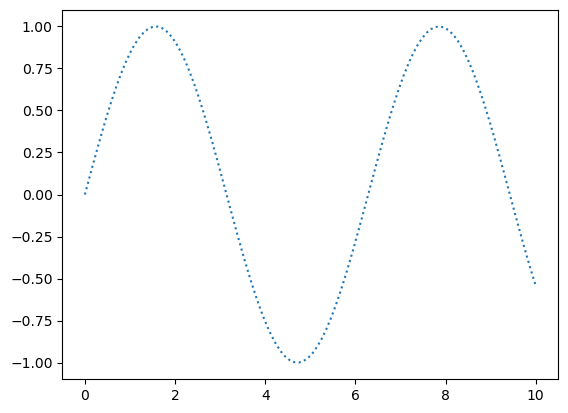

In [87]:
x = torch.linspace(0, 10, 100)
y = torch.sin(x)
plt.plot(x, y, ':');

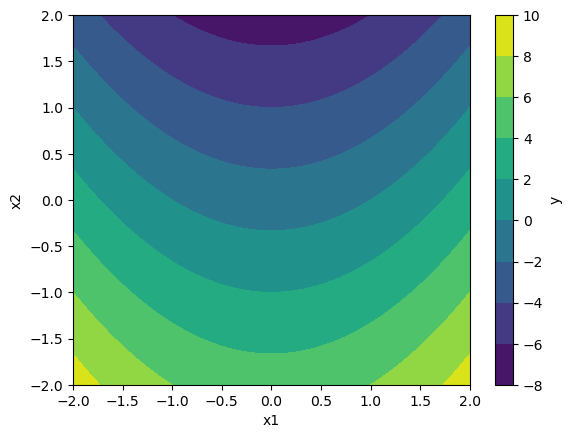

In [100]:
x1 = torch.linspace(-2, 2, 100)
x2 = torch.linspace(-2, 2, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing='xy')
Y =  X1 ** 2 + -3 * X2 - 1

cs = plt.contourf(x1, x2, Y);
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(cs, label='y');


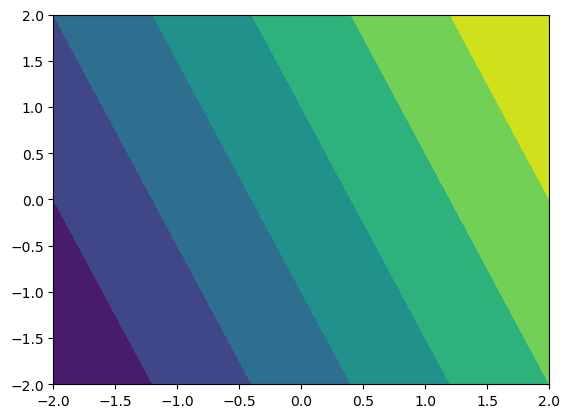

In [105]:
x1 = torch.linspace(-2, 2, 100)
x2 = torch.linspace(-2, 2, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing='xy')
Y =  5 * X1 + 2 * X2 - 10

plt.contourf(x1, x2, Y);


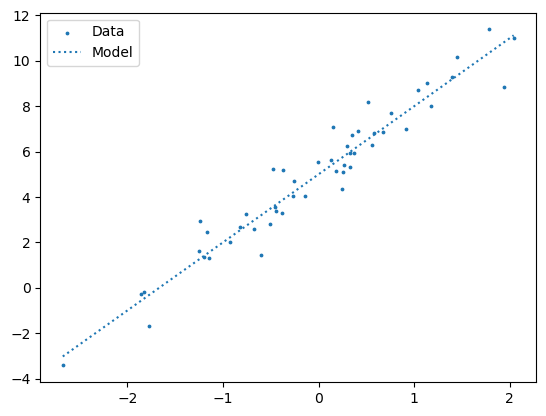

In [112]:

x = torch.empty(50).normal_()
noise = torch.empty(50).normal_()
y = 3 * x + 5 + noise

x0 = torch.linspace(x.min(), x.max(), 50)
y0 = 3 * x0 + 5


plt.scatter(x, y, 3., label='Data')
plt.plot(x0, y0, ':', label='Model')
plt.legend();


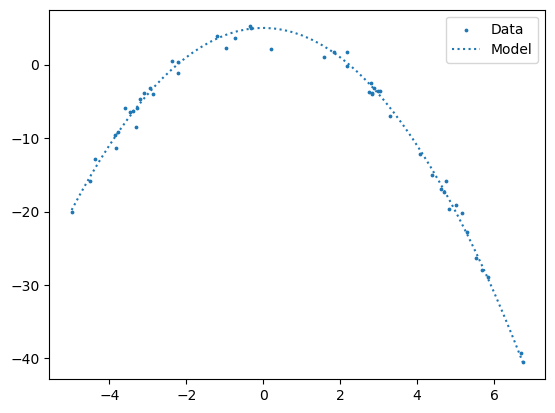

In [114]:

x = torch.empty(50).uniform_(-5, 7)
noise = torch.empty(50).normal_()
y = -1 * x ** 2 + 5 + noise

x0 = torch.linspace(x.min(), x.max(), 50)
y0 = -1 * x0 ** 2 + 5


plt.scatter(x, y, 3., label='Data')
plt.plot(x0, y0, ':', label='Model')
plt.legend();


## Comparing the Model's Predictions to the Observed Data: "Loss"

### Exercises

#### Util Functions

In [ ]:
def generate_data():
    """Generates Consistent, Random Data with hidden parameters."""
    
    n_samples = 30
    g = torch.Generator().manual_seed(125)

    # Generate Data Parameters
    weight = torch.empty(1).uniform_(-6, 6, generator=g)
    bias = torch.empty(1).uniform_(-8, 8, generator=g) 

    # Generate Data
    x = torch.empty(n_samples).normal_(generator=g)
    noise = torch.empty(n_samples).normal_(generator=g)
    y = weight * x + bias + noise

    # Return x and y
    return x, y



def linear_model(weight, bias):
    def model(x):
        return weight * x + bias
    return model

Text(0.5, 1.0, 'Loss: 0.83')

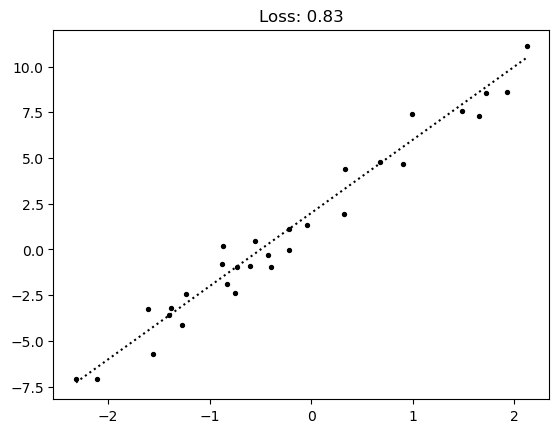

In [299]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model = linear_model(weight=4, bias=2)
    
# Check the Model's Predictions Against the Observed Data
y_pred = model(x)
loss = (y_pred - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model(x0), ':k');
plt.title(f'Loss: {loss.item():.2}')

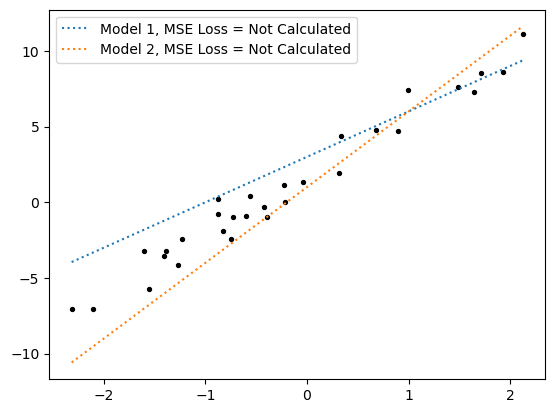

In [328]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model1 = linear_model(weight=3, bias=3)
model2 = linear_model(weight=5, bias=1)
    
# Check the Model's Predictions Against the Observed Data
y_pred1 = model1(x)
y_pred2 = model2(x)
loss1 = 0. #(y_pred1 - y_obs).square().mean()
loss2 = 0. #(y_pred2 - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model1(x0), ':', label=f'Model 1, MSE Loss = {round(loss1, 2) if loss1 else 'Not Calculated'}');
plt.plot(x0, model2(x0), ':', label=f'Model 2, MSE Loss = {round(loss2, 2) if loss2 else 'Not Calculated'}');
plt.legend();


## Improving the Model: Minimizing Loss By Modifying Model Parameters

### Utils

In [332]:
loss_function = nn.MSELoss()

### Exercises

In [ ]:
torch.manual_seed(42)

x, y_obs = generate_data()

# Model the Data
model = linear_model(weight=4, bias=2)
    
# Check the Model's Predictions Against the Observed Data
y_pred = model(x)
loss = (y_pred - y_obs).square().mean()

# Plot the Model Against the Data
plt.scatter(x, y_obs, 8, 'k')
x0 = torch.linspace(x.min(), x.max(), 2);  
plt.plot(x0, model(x0), ':k');
plt.title(f'Loss: {loss.item():.2}')

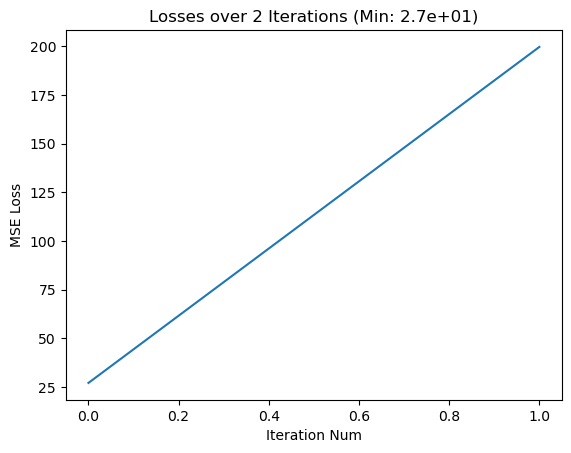

In [364]:
torch.manual_seed(42)

# Generate Data
x, y_obs = generate_data()

# Update the Model Parameters
num_iterations = 2  # UPDATE ME!

losses = []
for iteration in range(1, num_iterations + 1):

    # Randomly Guess the Model Parameters
    weight = torch.empty(1).uniform_(-10, 10)
    bias = torch.empty(1).uniform_(-10, 10)

    # Check the Model's Predictions Against the Observed Data
    model = linear_model(weight, bias)
    y_pred = model(x)
    loss = loss_function(y_pred, y_obs)
    losses.append(loss)


# Plot the Loss for each Iteration
plt.plot(losses)
plt.title(f'Losses over {iteration} Iterations (Min: {min(losses):.2})')
plt.xlabel('Iteration Num')
plt.ylabel('MSE Loss');



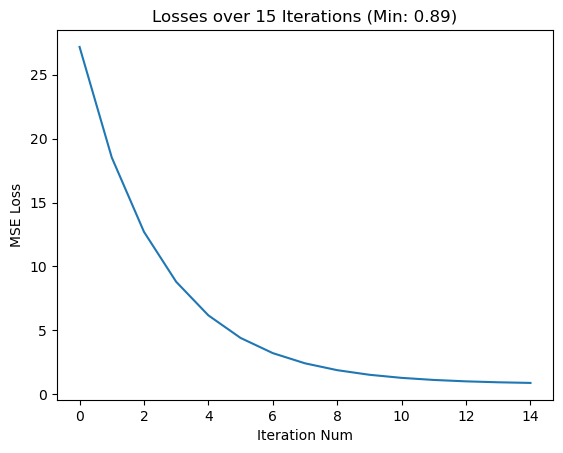

In [368]:
torch.manual_seed(42)

# Generate Data
x, y_obs = generate_data()

# Randomly Guess the Model Parameters
num_iterations = 15  # UPDATE ME!

weight = torch.empty(1).uniform_(-10, 10).requires_grad_()
bias = torch.empty(1).uniform_(-10, 10).requires_grad_()

losses = []
for iteration in range(1, num_iterations + 1):

    # Forward Pass: Check the Model's Predictions
    if weight.grad is not None:
        weight.grad.zero_()
    if bias.grad is not None:
        bias.grad.zero_()

    model = linear_model(weight, bias)
    y_pred = model(x)
    loss = loss_function(y_pred, y_obs)
    losses.append(loss)

    # Backward Pass: Improve the Model based on the Loss Gradient
    loss.backward()  
    with torch.no_grad():
        weight -= weight.grad * .1
        bias -= bias.grad * .1


# Plot the Loss for each Iteration
plt.plot(tensor(losses))
plt.title(f'Losses over {iteration} Iterations (Min: {min(losses):.2})')
plt.xlabel('Iteration Num')
plt.ylabel('MSE Loss');

